In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('./hearing_test.csv')

In [3]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [4]:
df.tail()

,age,physical_score,test_result
4995,73.0,3.9,0
4996,57.0,33.9,1
4997,49.0,34.5,1
4998,38.0,46.4,1
4999,48.0,38.5,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [6]:
df.isna().sum()

age               0
physical_score    0
test_result       0
dtype: int64

In [7]:
x = df.drop('test_result', axis=1)
y= df['test_result']

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8)

In [9]:
from sklearn.svm import SVC

model = SVC()

model.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [10]:
y_predictions = model.predict(x_test)
print(y_predictions)

[0 0 0 1 1 0 0 0 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 0 0 1 0 1 1 1
 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 0 0 1 0 0 0 0 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 0 0 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0
 0 1 1 1 1 1 1 0 0 0 1 1 1 0 1 1 0 1 1 1 1 1 0 0 0 1 1 0 1 0 0 1 1 1 0 1 1
 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1 1 1 1 1 0 1 0 0
 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 0 0 1 0 1 0
 0 1 0 0 1 0 1 0 1 1 1 0 1 0 1 0 0 1 1 0 1 1 0 0 0 0 1 0 1 1 1 1 0 0 1 0 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0
 0 0 1 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0 0 1 0 1 0 1 0 1 1 1 1
 1 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 0 0 0 1 0 1 1 1 1 0 0 0
 1 0 1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 0 0 1 0 0 1 0 1 1 0 1
 1 1 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1
 0 0 0 1 1 0 1 0 1 0 0 0 

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [18]:
cm = confusion_matrix(y_test, y_predictions)
print(cm)

[[341  49]
 [ 19 591]]


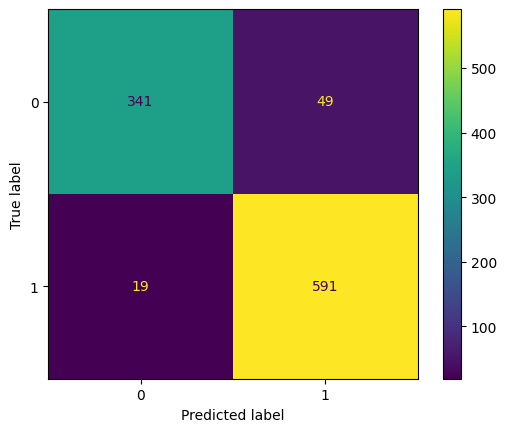

In [19]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.show()

In [20]:
print(f"Right prections = {cm[0,0] + cm[1,1]}")

Right prections = 932


In [21]:
score = accuracy_score(y_test, y_predictions)
print(f"Accuracy score = {score}")

Accuracy score = 0.932


In [22]:
from sklearn.metrics import precision_score, recall_score

In [23]:
pscore = precision_score(y_test, y_predictions)
print(f"Precision score = {pscore}")

Precision score = 0.9234375


In [24]:
rscore = recall_score(y_test, y_predictions)
print(f"Recall score = {rscore}")

Recall score = 0.9688524590163935


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predictions))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91       390
           1       0.92      0.97      0.95       610

    accuracy                           0.93      1000
   macro avg       0.94      0.92      0.93      1000
weighted avg       0.93      0.93      0.93      1000

